# Week 4: Variable Discovery via Sparse Gating\n
\n
In this notebook, we answer the question: **What drives the regimes?**\n
\n
## Method\n
- We train the **Gating Network** with **L1 Regularization** on its input weights.\n
- This forces the network to select only the most important features (e.g., Latitude, SST) to determine regime boundaries.\n
- We interpret the learned weights to discover the "Physical Drivers" of the regimes.

In [1]:
import sys
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import xarray as xr
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from scripts.preprocess import TRAIN_OUTPUT_PATH
from src.climate_discovery.models.gating import GatingNetwork
from src.climate_discovery.models.mixture import MixtureOfExperts
from src.climate_discovery.models.loss import L1SparseLoss

# 1. Load Data (Same as Week 3)
ds_train = xr.open_dataset(TRAIN_OUTPUT_PATH)
df = ds_train.to_dataframe().reset_index().dropna()

# Expanded Feature Set for Discovery: Is it just Space? Or Temperature? Or Bio?
df['lat_norm'] = df['lat'] / 90.0
df['lon_norm'] = df['lon'] / 180.0
gating_features = ['lat_norm', 'lon_norm', 'sin_month', 'cos_month', 'sst', 'sss', 'log_chl']
feature_names = gating_features

X_gate = torch.tensor(df[gating_features].values, dtype=torch.float32)
X_expert = torch.tensor(df[['sst', 'sss', 'log_chl']].values, dtype=torch.float32) # Expert needs its usuals
y = torch.tensor(df['fco2'].values, dtype=torch.float32)

# Pre-fit Dummy Experts (Linear) per KMeans Cluster
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
kmeans = KMeans(n_clusters=3, random_state=42).fit(X_expert)
expert_preds = np.zeros((len(y), 3))
for k in range(3):
    mask = (kmeans.labels_ == k)
    m = LinearRegression().fit(X_expert[mask], y[mask])
    expert_preds[:, k] = m.predict(X_expert)
expert_preds_tensor = torch.tensor(expert_preds, dtype=torch.float32)

print(f"Testing Features for Gating: {feature_names}")

Testing Features for Gating: ['lat_norm', 'lon_norm', 'sin_month', 'cos_month', 'sst', 'sss', 'log_chl']


In [2]:
# 2. Train with Sparsity
gating_net = GatingNetwork(input_dim=len(feature_names), num_regimes=3, hidden_dim=64)
moe = MixtureOfExperts(gating_net, [])
optimizer = optim.Adam(gating_net.parameters(), lr=0.005)
criterion = nn.MSELoss()
l1_loss = L1SparseLoss(weight=0.05) # Strong enough penalty to kill useless features

dataset = torch.utils.data.TensorDataset(X_gate, expert_preds_tensor, y)
loader = torch.utils.data.DataLoader(dataset, batch_size=2048, shuffle=True)

losses = []
l1_vals = []

print("Training with Sparse Gating...")
for epoch in range(15):
    for xg, ep, yb in loader:
        optimizer.zero_grad()
        y_hat, _ = moe.forward_with_precomputed(xg, ep)
        
        mse = criterion(y_hat, yb)
        sparsity = l1_loss(gating_net)
        
        loss = mse + sparsity
        loss.backward()
        optimizer.step()
    
    losses.append(mse.item()) # Log MSE
    l1_vals.append(sparsity.item()) # Log Sparsity
    if epoch % 5 == 0:
        print(f"Epoch {epoch}: MSE={mse.item():.4f}, L1={sparsity.item():.4f}")

Training with Sparse Gating...
Epoch 0: MSE=1195.3416, L1=4.0875
Epoch 5: MSE=743.5928, L1=4.1981
Epoch 10: MSE=1059.4045, L1=4.2799


Importance Ranking:
lat_norm: 0.2558
sst: 0.2240
sss: 0.2089
lon_norm: 0.1839
cos_month: 0.1788
sin_month: 0.1527
log_chl: 0.1463


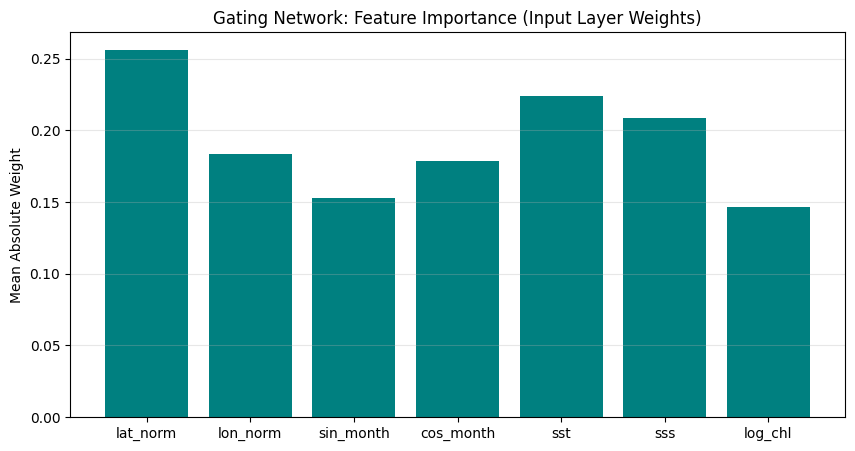

In [3]:
# 3. Interpret Feature Weights
first_layer = gating_net.net[0]
weights = first_layer.weight.detach().abs().mean(dim=0).numpy()

plt.figure(figsize=(10, 5))
plt.bar(feature_names, weights, color='teal')
plt.title("Gating Network: Feature Importance (Input Layer Weights)")
plt.ylabel("Mean Absolute Weight")
plt.grid(axis='y', alpha=0.3)

print("Importance Ranking:")
sorted_indices = np.argsort(weights)[::-1]
for i in sorted_indices:
    print(f"{feature_names[i]}: {weights[i]:.4f}")

# If SST or Bio has high weight, it means regimes are physically driven, not just geographical!